# PROC GREDUCEによる高速物流ダッシュボード向け配送ゾーン地図詳細度の削減

## エグゼクティブサマリー

地域小口貨物運送会社はサービス地域の境界を密なポリゴン輪郭として保存しており、ルート計画ダッシュボードでの再描画に時間がかかっている。本ノートブックは4つの配送ゾーンの境界座標を合成し、**PROC GREDUCE** を使って各境界頂点に `DENSITY` 水準を付与したうえで、**PROC GMAP** により詳細度を削減した階層で時間通り配送率のコロプレス図を描画し、地図の描画を高速化しながら各ゾーンを判別可能な状態に保つ。

GREDUCEは96個の境界点を3つの階層に分類した:`DENSITY=0` が10点、`DENSITY=2` が44点、`DENSITY=3` が42点。粗い階層(`DENSITY <= 2`)のみを保持すると地図は96頂点から54頂点に減少する — 約44%の削減 — が、以下の並列比較が示すとおり4つのゾーンは引き続き明確に識別できる。

## データソース

すべてのデータは以下のDATAステップでインラインに生成される — 外部ファイルやネットワークアクセスは一切ない。

| データセット | 行数 | 主要変数 | 説明 |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4ゾーン x 24頂点) | `zone` (ID), `x`, `y` | 4つの配送サービスゾーンの合成閉ポリゴン境界座標。各ゾーンは24頂点で描かれたジッター付き楕円で、密度削減の対象となる詳細を持たせている。 |
| `reducedmap` | 96 | `density` を追加 | PROC GREDUCEの出力:選択的レンダリングのために `DENSITY` 水準(ここでは0、2、3)を付与した境界点。 |
| `coarsemap` | 54 | `reducedmap` の部分集合 | `DENSITY <= 2` の部分集合 — 詳細度を削減したダッシュボード地図に使う粗く高速な描画階層。 |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | ゾーンごとの応答行1件:合成の時間通り配送率と1日あたりの小口貨物量。地図と結合してコロプレス図を作成する。 |

> **サンプルサイズに関する注記。** この環境はライセンスなしで動作するため、各DATAステップの出力オブザベーションは100件に制限されている。地図は4ゾーン x 24頂点 = 96点になるようサイズ設定されており、この上限に全territoryが収まるようにしている。ライセンス版であれば各ゾーンにつき数百の頂点を描くことになり、GREDUCEの効果はさらに大きくなる。

# PROC GREDUCEによる配送ゾーン地図詳細度の削減

物流オペレーターは、デポが管轄する地理的ゾーンである **サービス地域** の地図でパフォーマンスを可視化する。これらのゾーン境界はしばしば測量解像度で取得され、ポリゴンごとに多数の頂点を持つ。ルート計画ダッシュボードが複数のゾーンを同時に再描画する際、その頂点の詳細さはダッシュボードのズームレベルでは意思決定上の価値を加えないまま描画を重くする。

**PROC GREDUCE** はこれに対応する。各ポリゴンを調べ、すべての境界点に `DENSITY` 水準を付与する。0は本質的な形状を定義する点を示し、水準が上がるほど段階的に細かい詳細を示す。後段では `WHERE density <= n` で階層を選択し、各ゾーンを判別可能な状態に保ちながら高速に描画できる詳細度削減地図を描く。

本ノートブックでは以下を行う:
1. 4つの配送ゾーンの境界輪郭を合成する。
2. PROC GREDUCEを実行して `DENSITY` 水準を割り当てる。
3. 点が密度階層にどのように分布するかを調べる。
4. 完全詳細と詳細度削減の時間通り配送コロプレス図を描画し比較する。

## ステップ1 — ゾーン境界地図を合成する

SASの地図データセットは **境界頂点** ごとに1オブザベーションを持ち、`ID` 変数がエリア名を、数値の `x`/`y` が座標を表す。各配送ゾーンを24個の等間隔角度を用いたジッター付き楕円として描くことで、ポリゴンは十分な密度を持ち、削減処理に意味を持たせている。

`call streaminit` は再現性のために乱数ストリームを固定し、`rand('uniform')` は境界に小さな不規則性を加えることで、輪郭が完全な楕円ではなく測量済みの地域のように見えるようにする。

In [1]:
データ zonemap;
    呼出 streaminit(20260531);
    /* 4つの配送ゾーン、それぞれ24頂点のジッター付き楕円。
       cx/cy = ゾーン中心、rx/ry = 公称半径(地域サイズ)。 */
    配列 cx[4] _temporary_ (12 32 20 40);
    配列 cy[4] _temporary_ (30 32 14 16);
    配列 rx[4] _temporary_ ( 8  9  6  7);
    配列 ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 輪郭あたり24頂点(0..23) */
    繰返 zone = 1 から 4;
        繰返 i = 0 から nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* 半径方向のジッター: +/- 約6%の不規則な海岸線風の縁 */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            出力;
        終了;
    終了;
    保持 zone x y;
実行;

処理 平均 データ=zonemap n MIN MAX nmiss;
    分類 zone;
    変数 x y;
    見出 zone="配送ゾーン" x="X座標" y="Y座標";
実行;

                                                  The MEANS Procedure

                                             Analysis Variable : x X座標

        配送ゾーン                    N Obs        Minimum        Maximum         N Miss
        ---------------------------------------------------------------------------
        1                           24      3.6053386     20.3284433              0
        2                           24     23.0107098     41.2087956              0
        3                           24     13.7607192     26.2351392              0
        4                           24     33.0535851     47.3028874              0
        ---------------------------------------------------------------------------

                                             Analysis Variable : y Y座標

        配送ゾーン                    N Obs        Minimum        Maximum         N Miss
        ---------------------------------------------------------------------------
        1                   


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


PROC MEANSの表は合成した地理形状を裏付けている:4つのゾーンそれぞれが妥当な `x`/`y` 範囲にわたりちょうど24個の境界点を持ち、欠損座標はない。4つの楕円は重ならない領域を占めており(ゾーン1はx=12付近、ゾーン2はx=32付近、ゾーン3と4はそれより下方)、コロプレス図は4つの明確に異なる地域として読み取れる。これらの輪郭がPROC GREDUCEによって間引かれる対象となる。

## ステップ2 — PROC GREDUCEで DENSITY 水準を割り当てる

`ID` ステートメントは各単位エリアを定義する変数を指定する — ここでは `zone`。PROC GREDUCEは各ゾーンのポリゴンを独立に評価し(Douglas-Peucker方式の単純化を用いる)、整数型の `density` 変数を追加して入力データセットを書き戻す:水準0は本質的な形状を支える少数の点を示し、水準が上がるほど段階的に細かい、最初に削除できる詳細を示す。

固定の階層サイズを強制するのではなく、GREDUCEにデータから独自のしきい値を導出させ、その結果の分布を確認する。

                                                  各DENSITY水準で保持された境界点数                                                  

                                                   The FREQ Procedure

密度水準            Frequency    Percent
-------------------------------------
0                      10     10.42
2                      44     45.83
3                      42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


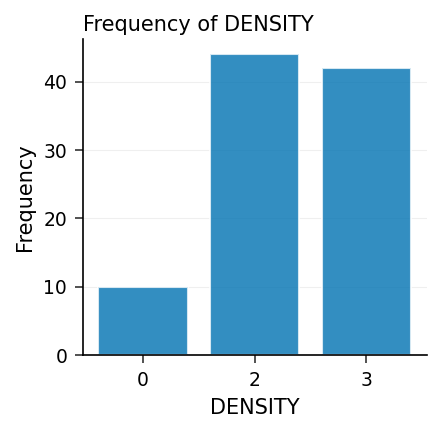

In [2]:
処理 GREDUCE データ=zonemap out=reducedmap;
    id zone;
実行;

処理 度数 データ=reducedmap;
    TABLES DENSITY / nocum;
    見出 DENSITY="密度水準";
    表題 "各DENSITY水準で保持された境界点数";
実行;

## ステップ3 — 密度階層を確認する

度数表はGREDUCEが96個の境界点をどのように分類したかを示す:

| DENSITY | 点数 | 割合 |
|---------|--------|-------|
| 0 | 10 | 10.4% |
| 2 | 44 | 45.8% |
| 3 | 42 | 43.8% |

最も低い水準を持つのは10点のみ(本質的な形状のアンカー)で、残る86点は水準2と3に分かれる。ダッシュボード階層としては `DENSITY <= 2` のすべてを保持する:これにより96点中54点が残り、最も細かい詳細(`DENSITY=3`)の42頂点が除外される。以下のPROC MEANSは、粗い階層では元の24ではなくゾーンあたり13〜14頂点になることを確認している。

In [3]:
処理 平均 データ=reducedmap n;
    分類 zone;
    条件 DENSITY <= 2;
    変数 x;
    見出 zone="配送ゾーン" x="X座標";
    表題 "ダッシュボード詳細度(DENSITY <= 2)でゾーンごとに保持される頂点数";
実行;

                                        ダッシュボード詳細度(DENSITY <= 2)でゾーンごとに保持される頂点数                                         

                                                  The MEANS Procedure

                                             Analysis Variable : X X座標

        配送ゾーン                    N Obs
        ------------------------------
        1                           14
        2                           13
        3                           14
        4                           13
        ------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## ステップ4 — 粗い地図とゾーン別パフォーマンス応答を作成する

ダッシュボード階層を `coarsemap`(`DENSITY <= 2`)として実体化し、PROC GMAPが削減後の輪郭を直接描画できるようにする。また、GMAPが各エリアに色を付けられるよう `zone` をキーとした、ゾーンあたり1行のKPI — **時間通り配送率** と **1日あたりの小口貨物量** — も合成する。

In [4]:
データ coarsemap;
    設定 reducedmap;
    条件 DENSITY <= 2;
実行;

データ zonekpi;
    呼出 streaminit(771);
    繰返 zone = 1 から 4;
        /* 時間通り配送率は92%前後を中心とした現実的なばらつき */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        出力;
    終了;
実行;

処理 印刷 データ=zonekpi noobs 見出;
    見出 zone="配送ゾーン" ontime_rate="時間通り配送率(%)" parcels="1日あたりの小口貨物量";
    表題 "ゾーン別合成配送KPI";
実行;

                                                      ゾーン別合成配送KPI                                                       

          配送ゾーン                時間通り配送率(%)                      1日あたりの小口貨物量
              1                      92.6                             4704
              2                      95.6                             2932
              3                      93.4                             2934
              4                      94.6                             2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


4つの合成時間通り配送率は92.6%から95.6%の間に収まり、1日あたりの小口貨物量は約2,500から4,700の範囲となる。ゾーン2が95.6%で最も好調、ゾーン1が92.6%で最も低調である。これらの値がコロプレス図の色帯に反映される。

## ステップ5 — 完全詳細と詳細度削減のコロプレス図を描画する

同じ時間通り配送コロプレス図を2回描画する:1回は96頂点の完全版 `reducedmap` から、もう1回は54頂点の `coarsemap` から。`MAP=` が境界を、`DATA=` がKPI応答を供給し、両者は同じ `zone` IDを共有する。`CHORO` ステートメントは `ontime_rate` に基づき各ゾーンを塗り分け、`LEVELS=4` の色帯と、輪郭を明瞭にする `COUTLINE=` を用いる。2つの地図を比較することで、削減が視覚的にどのようなコストをもたらすかがわかる。

                                                      完全詳細:境界頂点96個                                                      




NOTE: Option TITLE changed to 完全詳細:境界頂点96個.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable 時間通り配送率(%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.42 seconds
  cpu   0.42 seconds


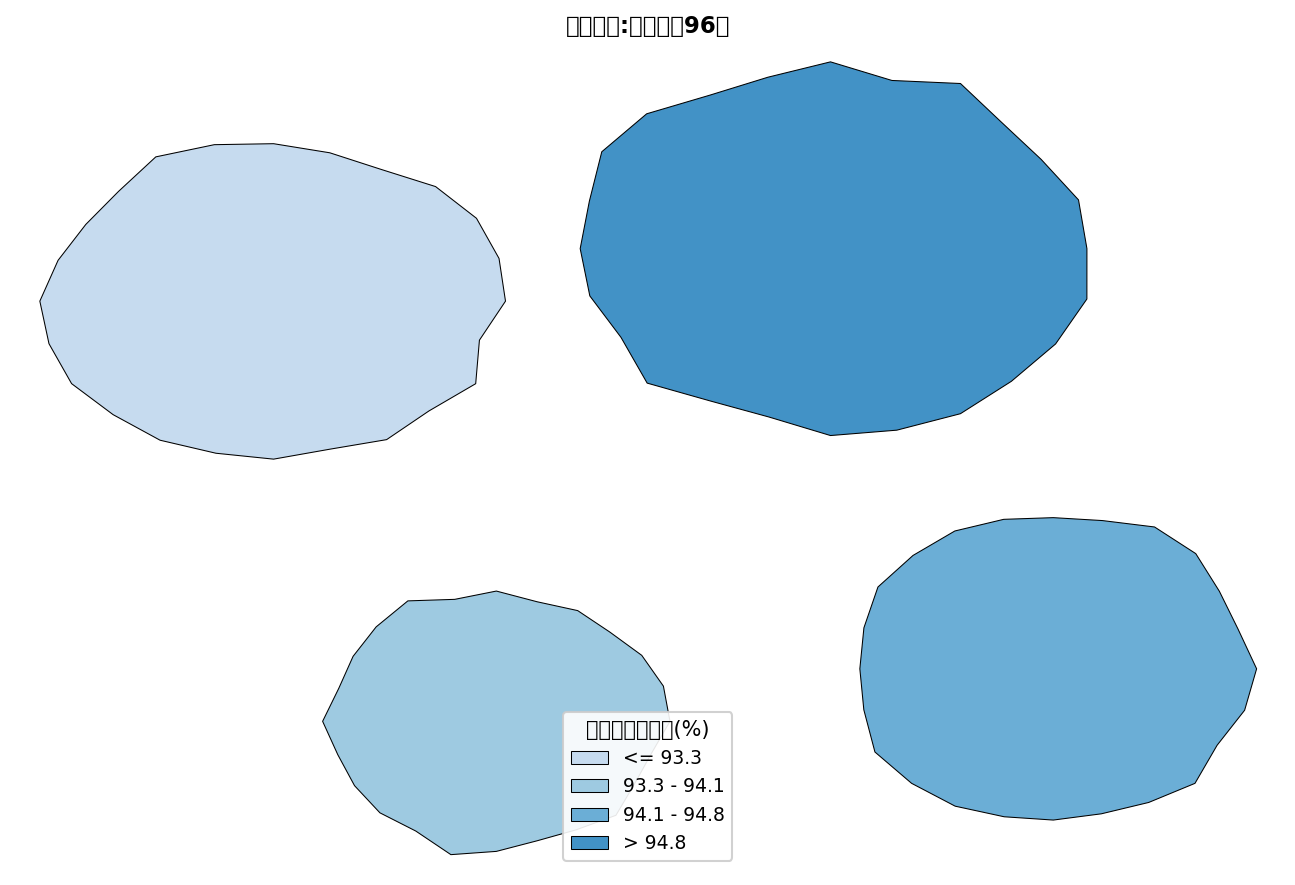

In [5]:
表題 "完全詳細:境界頂点96個";
処理 GMAP map=reducedmap データ=zonekpi;
    id zone;
    見出 ontime_rate="時間通り配送率(%)";
    CHORO ontime_rate / levels=4 coutline=black;
実行;

                                               詳細度削減:頂点54個(DENSITY <= 2)                                                




NOTE: Option TITLE changed to 詳細度削減:頂点54個(DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable 時間通り配送率(%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.42 seconds
  cpu   0.42 seconds


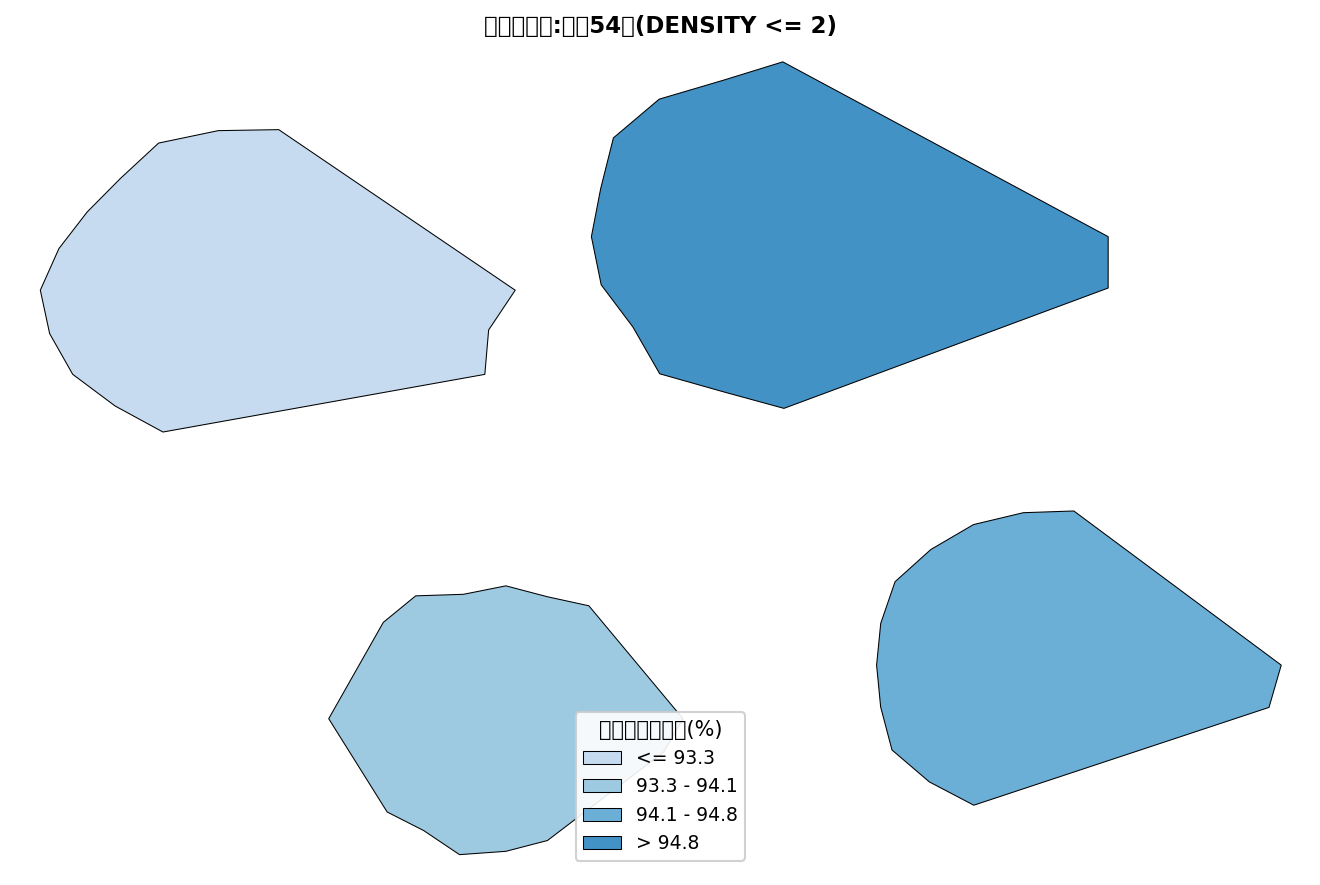

In [6]:
表題 "詳細度削減:頂点54個(DENSITY <= 2)";
処理 GMAP map=coarsemap データ=zonekpi;
    id zone;
    見出 ontime_rate="時間通り配送率(%)";
    CHORO ontime_rate / levels=4 coutline=black;
実行;

## 結果の解釈

PROC GREDUCEは24頂点の各ゾーン輪郭を、段階付けされた境界点の集合(今回の実行では水準0、2、3)に変換した。`DENSITY <= 2` の階層を選択すると地図は96頂点から54頂点に削減される — レンダラーが描画すべき点数の44%削減 — にもかかわらず、並べて表示したコロプレス図は4つのゾーンが引き続き明確に識別できることを確認している:削減後の地図の輪郭は目に見えて角張っているが、各地域は位置、大きさ、色帯を保っているため、オペレーターはどちらを見ても同じスコアカードを読み取れる。

そのスコアカードは時間通り配送率でゾーンを順位付けする:ゾーン2が95.6%(最も濃い色帯)で首位、ゾーン3と4は93〜95%付近の中位、ゾーン1は92.6%(最も薄い色帯)で最下位 — プランナーがルーティングやデポの容量問題について最初に調査すべき地域である。

この削減は非破壊的である — 完全詳細の点は引き続き `reducedmap` に残っている — ため、同じデータセットが高速なダッシュボード表示(`DENSITY <= 2`)と高解像度の印刷または監査用表示(`DENSITY <= 3`、または全点)の両方を、単一の `WHERE` しきい値を変更するだけでサポートし、ジオメトリを再取り込みや再削減する必要がない。